In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'

In [2]:
import os
import sys

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [3]:
import celloracle as co
co.__version__

/home/a3d9h01010/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


'0.20.0'

In [5]:
#plt.rcParams["font.family"] = "arial"
plt.rcParams["figure.figsize"] = [6,6]
%config InlineBackend.figure_format = 'retina'
plt.rcParams["savefig.dpi"] = 300

%matplotlib inline

In [6]:
# Make folder to save plots
save_folder = "./13 虚拟敲除/"
os.makedirs(save_folder, exist_ok=True)

In [7]:
###Load scRNA data
adata = sc.read_h5ad('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')


In [16]:
adata

AnnData object with n_obs × n_vars = 33068 × 18144
    obs: 'sample', 'n_genes', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'bbknn_leiden_0.5', 'harmony_leiden_0.5', 'harmony_leiden_0.2', 'Major_annotation', 'doublet_score', 'predicted_doublet', 'd_harmony_leiden_0.2', 'Major_annotation_d', 'Gr_subannotation', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'dpt_pseudotime', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_coun

In [52]:
### 预处理
adata_count=adata.copy()

In [53]:
adata_count.X=adata_count.layers['counts'].copy()

In [54]:
### 不用高边基因 adata_count=adata_count[:,adata_count.var['highly_variable']]
# Renormalize after filtering
sc.pp.normalize_per_cell(adata_count)

In [55]:
### 导入小鼠GRN网络
# Load TF info which was made from mouse cell atlas dataset.
base_GRN = co.data.load_mouse_scATAC_atlas_base_GRN()

# Check data
base_GRN.head()

,peak_id,gene_short_name,9430076c15rik,Ac002126.6,Ac012531.1,Ac226150.2,Afp,Ahr,Ahrr,Aire,...,Znf784,Znf8,Znf816,Znf85,Zscan10,Zscan16,Zscan22,Zscan26,Zscan31,Zscan4
0,chr10_100050979_100052296,4930430F08Rik,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr10_101006922_101007748,SNORA17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,chr10_101144061_101145000,Mgat4c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,chr10_10148873_10149183,9130014G24Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr10_10149425_10149815,9130014G24Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
## make oracle object
oracle=co.Oracle()
# Instantiate Oracle object.
oracle.import_anndata_as_raw_count(adata=adata_count,
                                   cluster_column_name="Gr_subannotation",
                                   embedding_name="X_umap"
                                  )

### 导入转录因子信息
oracle.import_TF_data(TF_info_matrix=base_GRN)

18144 genes were found in the adata. Note that Celloracle is intended to use around 1000-3000 genes, so the behavior with this number of genes may differ from what is expected.


In [57]:
###KNN imputation
oracle.perform_PCA()
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]

n_comps = min(n_comps, 50)
print(n_comps)
n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=8)

###Save object
oracle.to_hdf5("./13 虚拟敲除/gr.celloracle.oracle")

###GRN calculation
links = oracle.get_links(cluster_name_for_GRN_unit="Gr_subannotation", alpha=10, verbose_level=10)
links.to_hdf5(file_path="./13 虚拟敲除/gr.celloracle.links")

10
cell number is :33068
Auto-selected k is :826


  0%|          | 0/6 [00:00<?, ?it/s]

Inferring GRN for GC_0...


  0%|          | 0/13896 [00:00<?, ?it/s]



--------------------------------------------------------------------------------
LokyProcess-38 failed with traceback: 
--------------------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/a3d9h01010/.local/lib/python3.10/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 176, in <module>
    process_obj = pickle.load(from_parent)
  File "/home/a3d9h01010/.local/lib/python3.10/site-packages/joblib/externals/loky/backend/synchronize.py", line 131, in __setstate__
    self._semlock = _SemLock._rebuild(*state)
FileNotFoundError: [Errno 2] No such file or directory


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
LokyProcess-32 failed with traceback: 
--------------------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/a3d9h01010/.lo

TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {EXIT(1)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [3]:
### 读入数据
## make oracle object
oracle=co.Oracle()
oracle = co.load_hdf5("./13 虚拟敲除/gr.celloracle.oracle")
links = co.load_hdf5("./13 虚拟敲除/gr.celloracle.links")

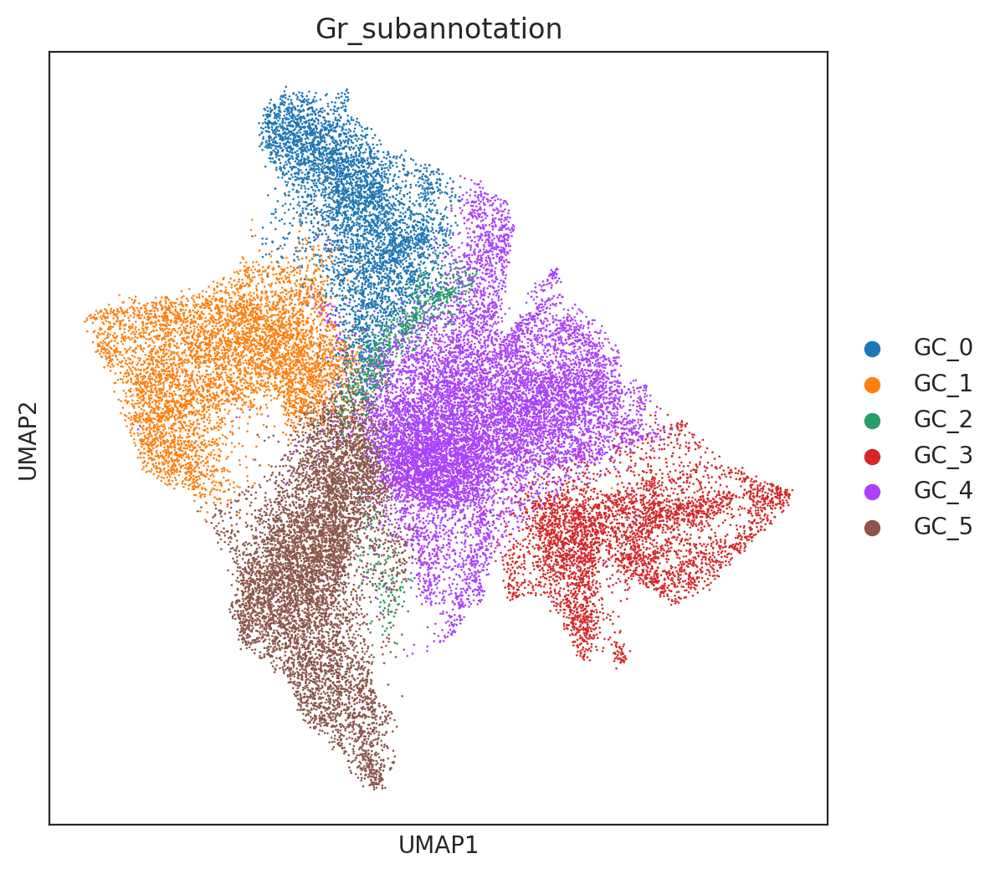

In [11]:
sc.pl.umap(oracle.adata, color=['Gr_subannotation'],show=True)
plt.show()

In [12]:
### 过滤GRN
links.filter_links(p=0.001,
    weight='coef_abs',
    #threshold_number=2000,
    genelist_source=None,
    genelist_target=None,
    thread_number=None)


In [13]:
key_uses=list(links.links_dict.keys())
print(key_uses)

['GC_0', 'GC_1', 'GC_2', 'GC_3', 'GC_4', 'GC_5']


In [14]:
# 获取 keys
key_uses = list(links.links_dict.keys())
print(key_uses)

# 保存每个 filtered_links 到 CSV
for key in key_uses:
    filename = f"./13 虚拟敲除/chosen_filtered_GRN_atac_for_{key}.csv"
    links.filtered_links[key].to_csv(filename)
    print(f"Saved: {filename}")  # 可选：确认输出

['GC_0', 'GC_1', 'GC_2', 'GC_3', 'GC_4', 'GC_5']
Saved: ./13 虚拟敲除/chosen_filtered_GRN_atac_for_GC_0.csv
Saved: ./13 虚拟敲除/chosen_filtered_GRN_atac_for_GC_1.csv
Saved: ./13 虚拟敲除/chosen_filtered_GRN_atac_for_GC_2.csv
Saved: ./13 虚拟敲除/chosen_filtered_GRN_atac_for_GC_3.csv
Saved: ./13 虚拟敲除/chosen_filtered_GRN_atac_for_GC_4.csv
Saved: ./13 虚拟敲除/chosen_filtered_GRN_atac_for_GC_5.csv


In [19]:
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10,
                              use_cluster_specific_TFdict=True)

  0%|          | 0/6 [00:00<?, ?it/s]

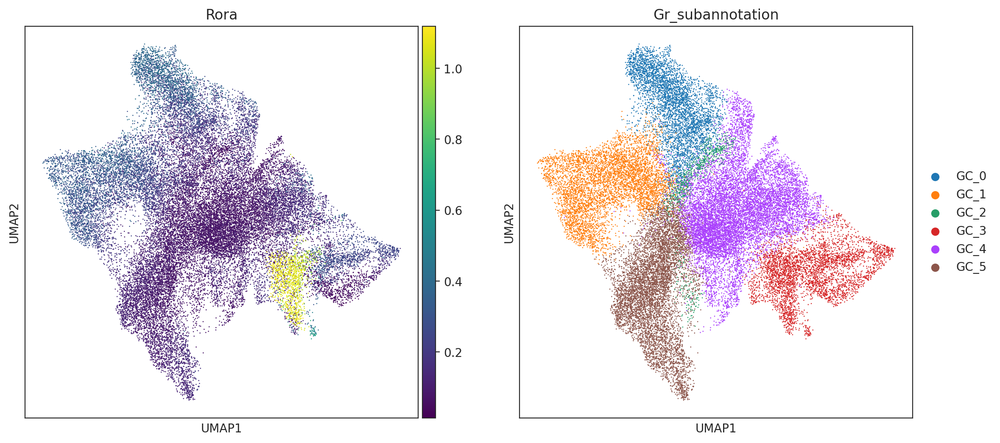

In [20]:
# Check gene expression
goi = "Rora"
sc.pl.umap(oracle.adata, color=[goi, oracle.cluster_column_name],
                 layer="imputed_count", use_raw=False, cmap="viridis")

In [22]:
# Enter perturbation conditions to simulate signal propagation after the perturbation.
oracle.simulate_shift(perturb_condition={goi: 0.0},
                      n_propagation=3)

In [23]:
# Get transition probability
oracle.estimate_transition_prob(n_neighbors=200,
                                knn_random=True,
                                sampled_fraction=1)

# Calculate embedding
oracle.calculate_embedding_shift(sigma_corr=0.05)

In [24]:
oracle.to_hdf5("./13 虚拟敲除/gr.celloracle.oracle")

### 读入结果

In [6]:
## make oracle object
oracle=co.Oracle()
oracle = co.load_hdf5("./13 虚拟敲除/gr.celloracle.oracle")

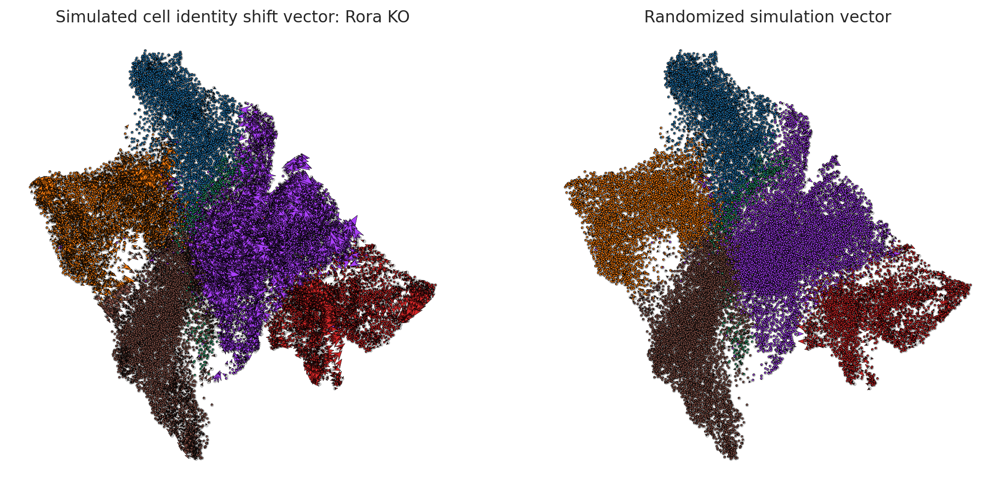

In [25]:
fig, ax = plt.subplots(1, 2,  figsize=[13, 6])

scale = 25
# Show quiver plot
oracle.plot_quiver(scale=scale, ax=ax[0])
ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")

# Show quiver plot that was calculated with randomized graph.
oracle.plot_quiver_random(scale=scale, ax=ax[1])
ax[1].set_title(f"Randomized simulation vector")

plt.show()

In [7]:
# n_grid = 40 is a good starting value.
n_grid = 40
oracle.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)

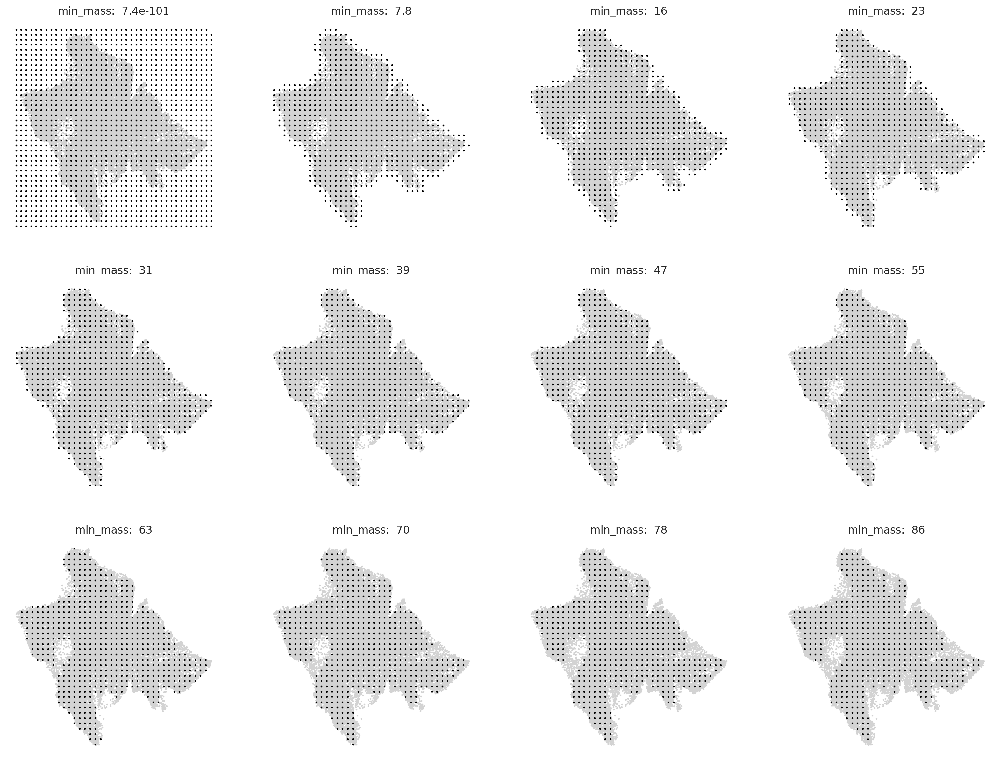

In [8]:
# Search for best min_mass.
oracle.suggest_mass_thresholds(n_suggestion=12)  #miss 细胞密度阈值

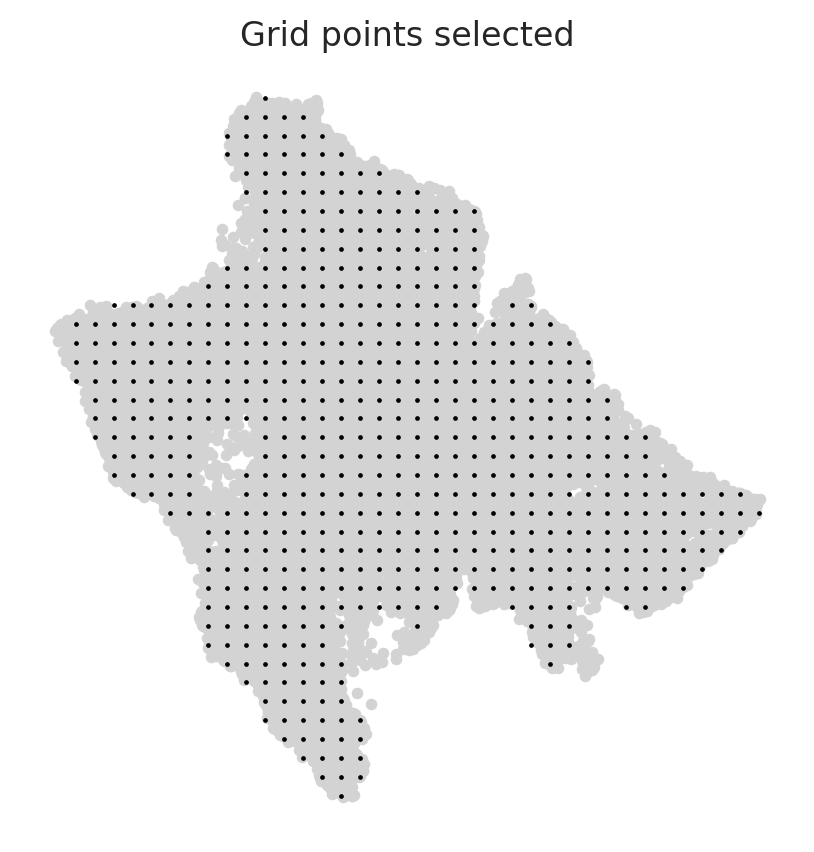

In [9]:
min_mass = 55
oracle.calculate_mass_filter(min_mass=min_mass, plot=True)

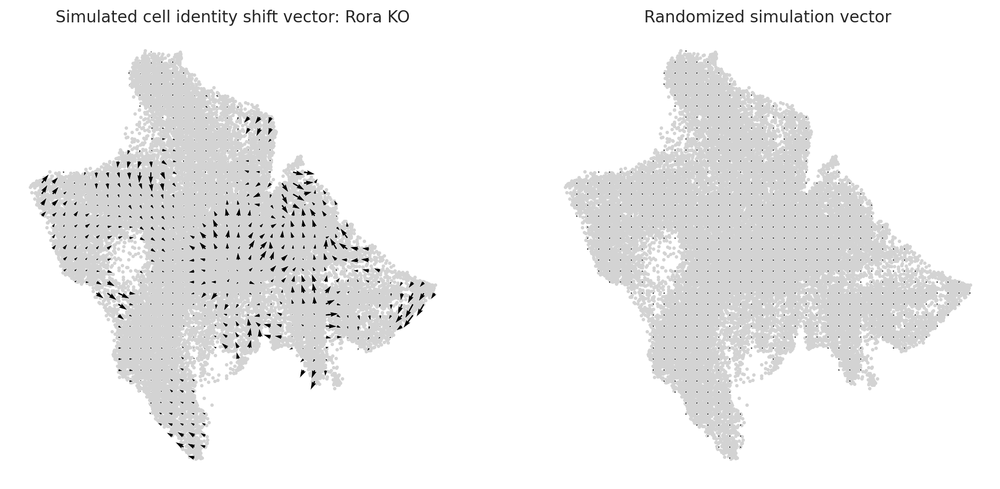

In [10]:
goi = "Rora"

fig, ax = plt.subplots(1, 2,  figsize=[13, 6])

scale_simulation = 10
# Show quiver plot
oracle.plot_simulation_flow_on_grid(scale=10, ax=ax[0])
ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")

# Show quiver plot that was calculated with randomized graph.
oracle.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1])
ax[1].set_title(f"Randomized simulation vector")

plt.show()

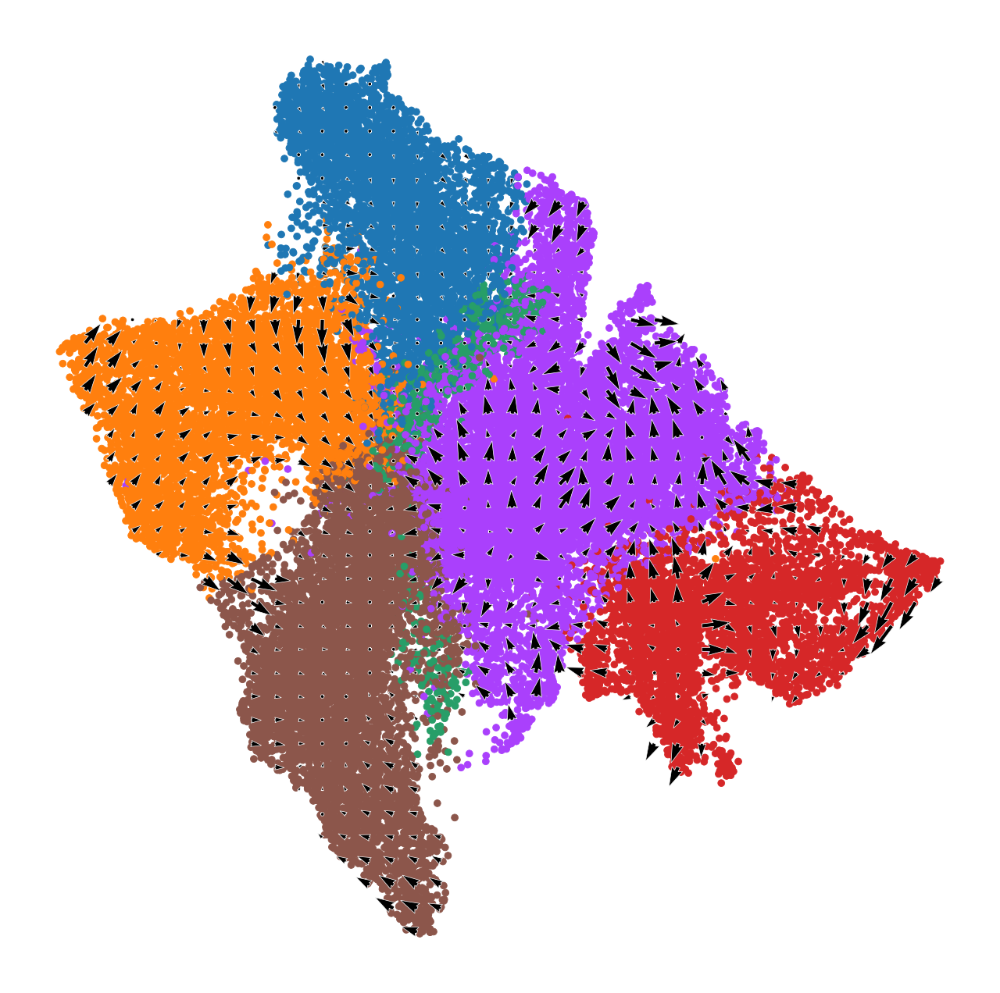

In [12]:
# Plot vector field with cell cluster
fig, ax = plt.subplots(figsize=[8, 8])

oracle.plot_cluster_whole(ax=ax, s=10)
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax, show_background=False)

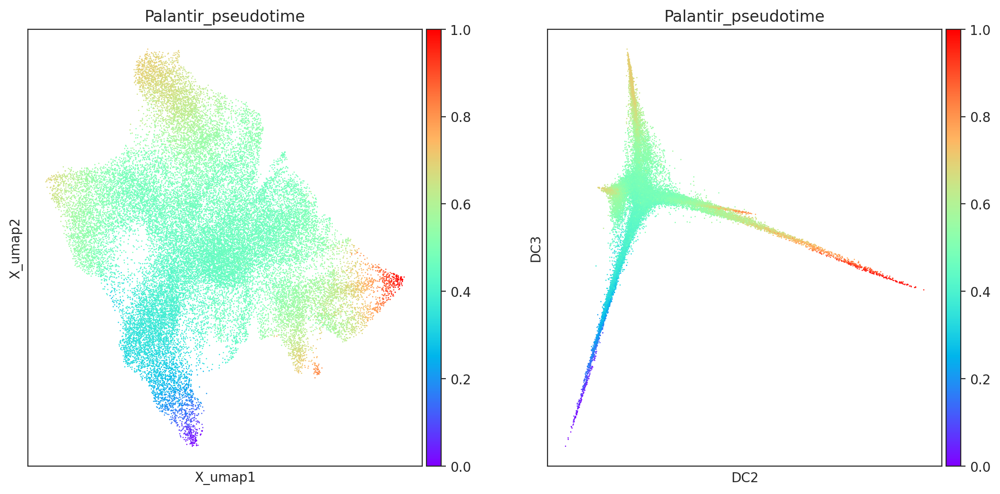

In [13]:
# Visualize pseudotime
fig, ax = plt.subplots(1, 2,  figsize=[13, 6])

sc.pl.embedding(adata=oracle.adata, basis=oracle.embedding_name, ax=ax[0], cmap="rainbow", show=False,
                color=["Palantir_pseudotime"])
sc.pl.embedding(adata=oracle.adata, basis='diffmap', ax=ax[1], cmap="rainbow", dimensions=[(1, 2)],show=False,
                color=["Palantir_pseudotime"])
plt.show()

In [11]:
from celloracle.applications import Gradient_calculator

# Instantiate Gradient calculator object
gradient = Gradient_calculator(oracle_object=oracle, pseudotime_key="Palantir_pseudotime")

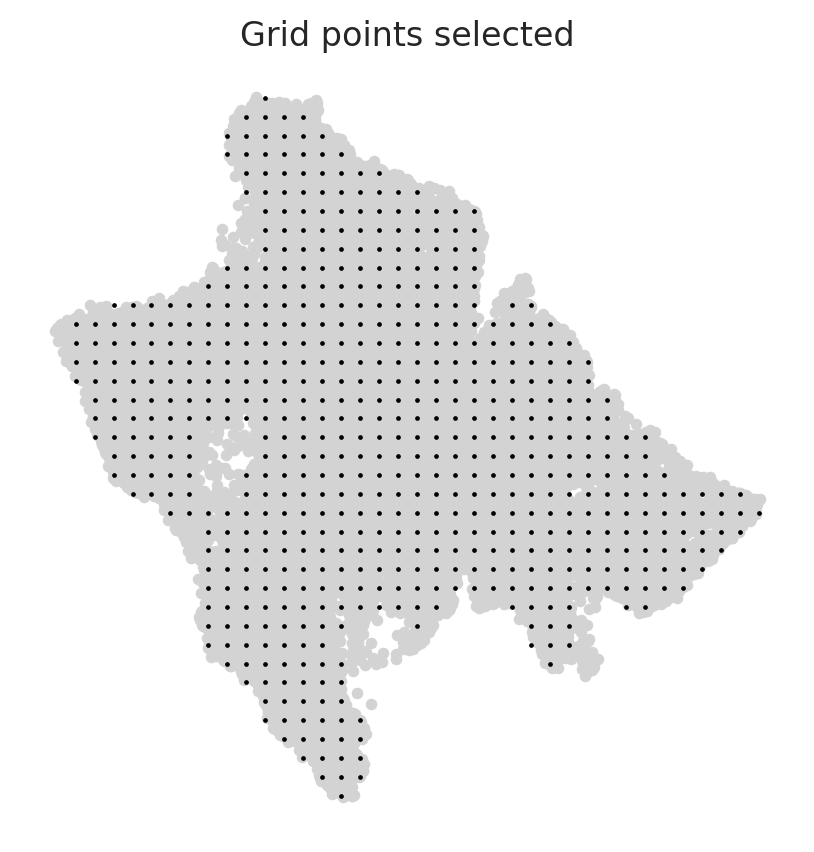

In [12]:
gradient.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=200)
gradient.calculate_mass_filter(min_mass=min_mass, plot=True)

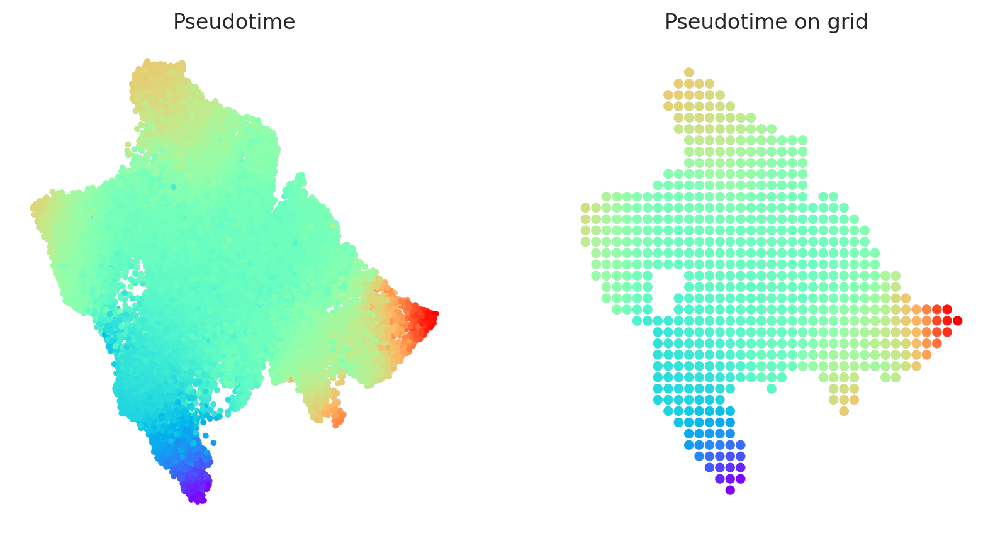

In [13]:
### 方法1 ： KNN
gradient.transfer_data_into_grid(args={"method": "knn", "n_knn":50},plot=True)

In [17]:
### 方法2： 泊松回归
gradient.transfer_data_into_grid(args={"method": "polynomial", "n_poly":3}, plot=False)

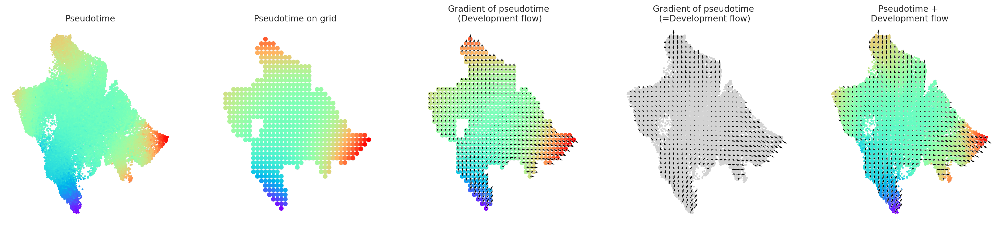

In [14]:
### 方法2： 泊松回归
gradient.transfer_data_into_grid(args={"method": "polynomial", "n_poly":3}, plot=False)
### 方法1 ： KNN
#gradient.transfer_data_into_grid(args={"method": "knn", "n_knn":30},plot=False)
gradient.calculate_gradient()

# Show results
scale_dev =40
gradient.visualize_results(scale=scale_dev, s=5)

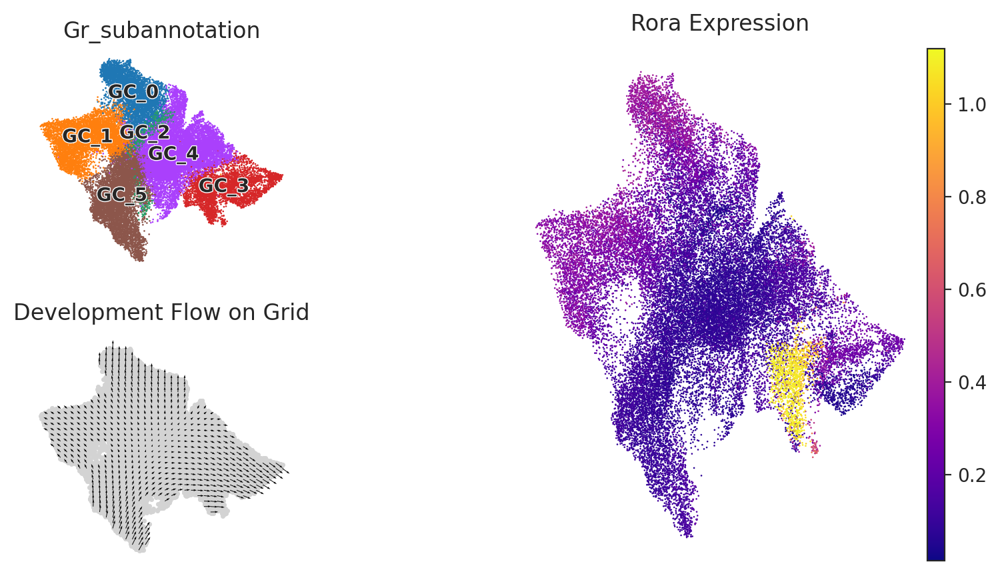

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.neighbors import NearestCenters

goi='Rora'
# 设置全局风格
sns.set_style("white")

# 创建图形
fig = plt.figure(figsize=(16*0.6, 8*0.6))  # 总体大小适中

# GridSpec：2x2，但只用3个格子
gs = fig.add_gridspec(2, 2,
                      width_ratios=[1, 1],     # 左右宽度相同
                      height_ratios=[1, 1],     # 上下高度相同
                      left=0.1, right=0.9,
                      top=0.9, bottom=0.1,
                      wspace=0.3, hspace=0.3)

# 第一个UMAP图：聚类 + 标注在数据点上
ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(oracle.adata, color=[oracle.cluster_column_name],
           layer="imputed_count", use_raw=False, cmap="viridis",legend_loc='on data',legend_fontoutline=True,
           ax=ax1, show=False)
ax1.axis('off')  # 去除坐标轴边框和标签
ax1.set_aspect('equal')  # 关键：强制正方形



# 第二个图：development flow on grid
ax2 = fig.add_subplot(gs[1, 0])
gradient.plot_dev_flow_on_grid(scale=scale_dev, ax=ax2)
ax2.set_title("Development Flow on Grid", fontsize=12, pad=10)
ax2.axis('off')  # 同样去除边框和坐标轴
ax2.set_aspect('equal')  # 关键：强制正方形


# 第三个 UMAP 图 （右侧行跨两行）
ax3 = fig.add_subplot(gs[:, 1])
sc.pl.umap(oracle.adata, color=[goi],
           layer="imputed_count", use_raw=False, cmap="plasma",
           ax=ax3, show=False)
ax3.set_title(f"{goi} Expression", fontsize=12, pad=10)
ax3.axis('off')


# 调整整体布局
plt.tight_layout()

# 保存为高质量 PDF
plt.savefig("./figures/13_celloracle_combined_visualization.pdf", format="pdf", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.neighbors import NearestCenters

goi='Rora'
# 设置全局风格
sns.set_style("white")

# 创建图形
fig = plt.figure(figsize=(16*0.6, 8*0.6))  # 总体大小适中

# GridSpec：2x2，但只用3个格子
gs = fig.add_gridspec(2, 2,
                      width_ratios=[1, 1],     # 左右宽度相同
                      height_ratios=[1, 1],     # 上下高度相同
                      left=0.1, right=0.9,
                      top=0.9, bottom=0.1,
                      wspace=0.3, hspace=0.3)

# 第一个UMAP图：聚类 + 标注在数据点上
ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(oracle.adata, color=[oracle.cluster_column_name],
           layer="imputed_count", use_raw=False, cmap="viridis",legend_loc='on data',legend_fontoutline=True,
           ax=ax1, show=False)
ax1.axis('off')  # 去除坐标轴边框和标签
ax1.set_aspect('equal')  # 关键：强制正方形



# 第二个图：development flow on grid
ax2 = fig.add_subplot(gs[1, 0])
gradient.plot_dev_flow_on_grid(scale=scale_dev, ax=ax2)
ax2.set_title("Development Flow on Grid", fontsize=12, pad=10)
ax2.axis('off')  # 同样去除边框和坐标轴
ax2.set_aspect('equal')  # 关键：强制正方形


# 第三个 UMAP 图 （右侧行跨两行）
ax3 = fig.add_subplot(gs[:, 1])
sc.pl.umap(oracle.adata, color=[goi],
           layer="imputed_count", use_raw=False, cmap="plasma",
           ax=ax3, show=False)
ax3.set_title(f"{goi} Expression", fontsize=12, pad=10)
ax3.axis('off')


# 调整整体布局
plt.tight_layout()

# 保存为高质量 PDF
plt.savefig("./figures/13_celloracle_combined_visualization.svg", format="pdf", bbox_inches='tight', dpi=300)
plt.show()

In [39]:
from celloracle.applications import Oracle_development_module

# Make Oracle_development_module to compare two vector field
dev = Oracle_development_module()

# Load development flow
dev.load_differentiation_reference_data(gradient_object=gradient)

# Load simulation result
dev.load_perturb_simulation_data(oracle_object=oracle)


# Calculate inner produc scores
dev.calculate_inner_product()
dev.calculate_digitized_ip(n_bins=10)

In [51]:
dev.inner_product_df.to_csv('./13 虚拟敲除/13_celloracle_inner_score.csv',index=True)

In [88]:
# 将二维数组转换为 DataFrame
# 将坐标和 pseudotime 合并成一个 DataFrame
df = pd.DataFrame({
    'Dim1': dev.gridpoints_coordinates[:, 0],
    'Dim2': dev.gridpoints_coordinates[:, 1],
    'mass_filter':dev.mass_filter_simulation,  #掩码值
    'flow_x':dev.flow[:,0],
    'flow_y':dev.flow[:,1],
    'ref_flow_x':dev.ref_flow[:,0],
    'ref_flow_y':dev.ref_flow[:,1],
})
# 将 DataFrame 保存为 CSV 文件
df.to_csv('./13 虚拟敲除/13_celloracle_gridpoints_coordinates.csv', index=False)

print("文件已成功保存为 'gridpoints_coordinates.csv'")

文件已成功保存为 'gridpoints_coordinates.csv'


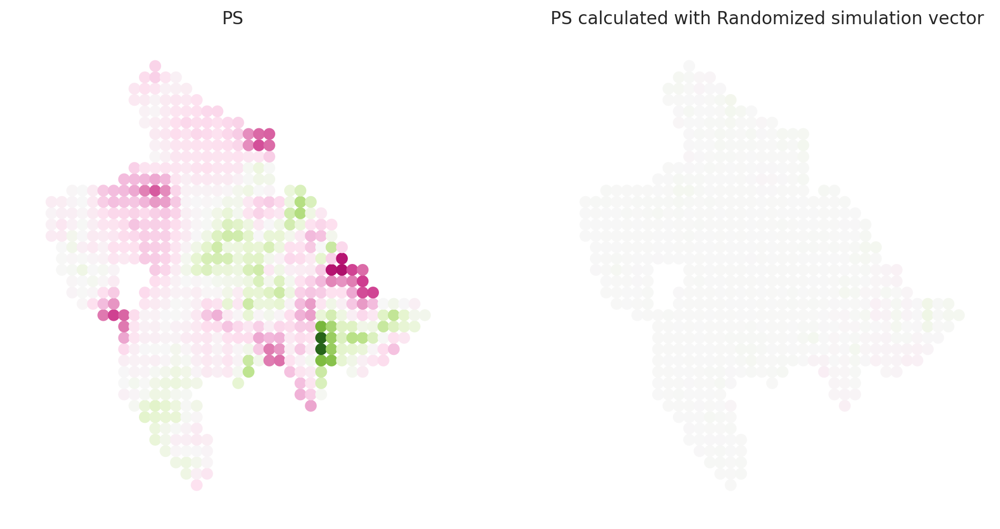

In [80]:
# Show perturbation scores
vm = 0.25

fig, ax = plt.subplots(1, 2, figsize=[12, 6])
dev.plot_inner_product_on_grid(vm=vm , s=50, ax=ax[0])
ax[0].set_title(f"PS")

dev.plot_inner_product_random_on_grid(vm=vm, s=50, ax=ax[1])
ax[1].set_title(f"PS calculated with Randomized simulation vector")
plt.show()

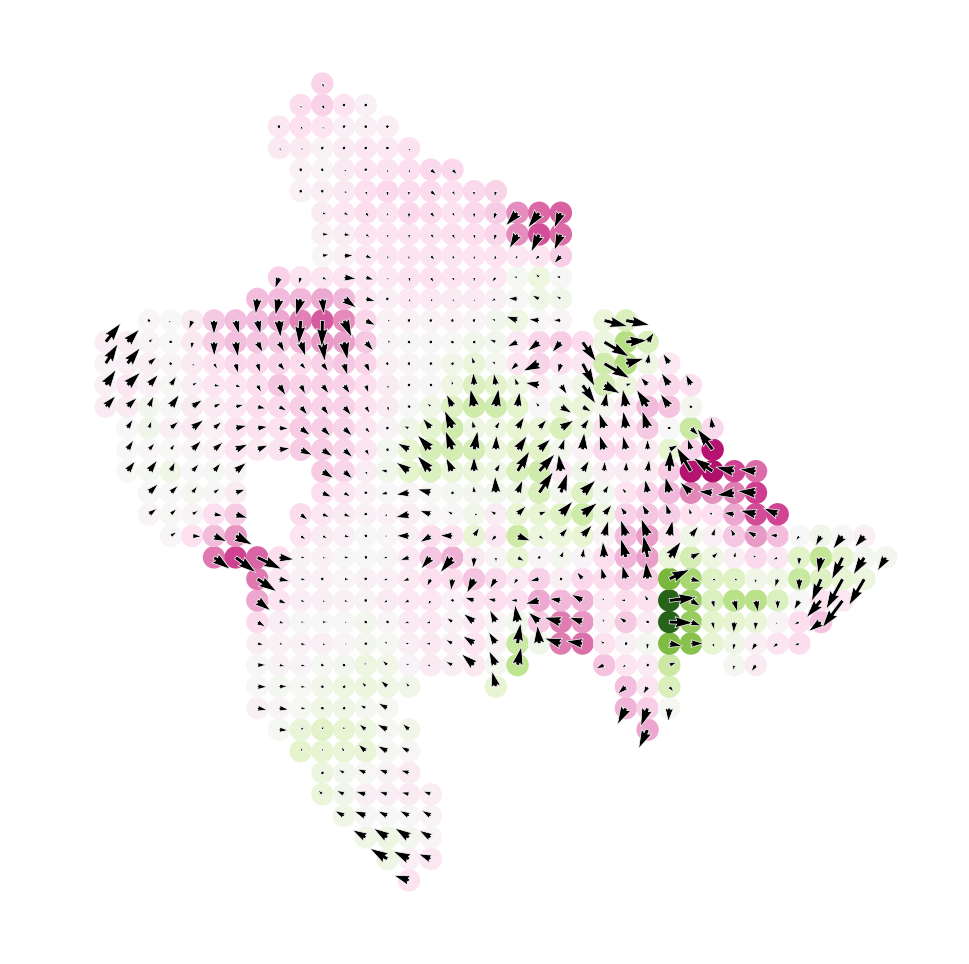

In [39]:
# Show perturbation scores with perturbation simulation vector field
fig, ax = plt.subplots(figsize=[6, 6])
dev.plot_inner_product_on_grid(vm=vm, s=50, ax=ax)
dev.plot_simulation_flow_on_grid(scale=scale_simulation, show_background=False, ax=ax)

2025-08-25 02:10:28,103 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-25 02:10:28,120 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


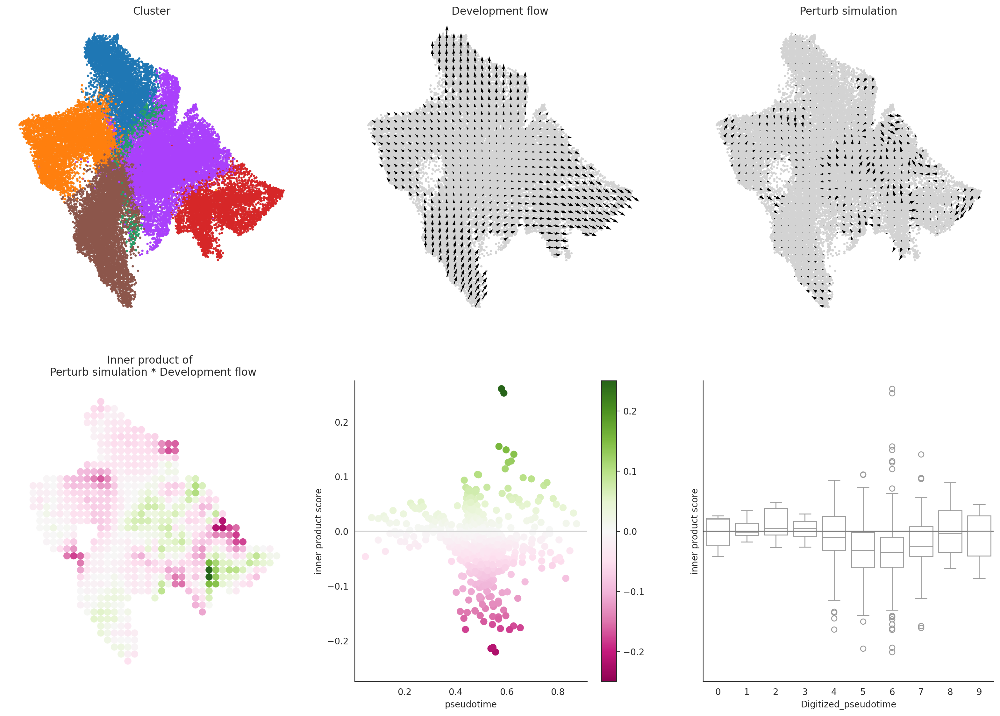

In [40]:
# Let's visualize the results
dev.visualize_development_module_layout_0(s=5,
                                          scale_for_simulation=scale_simulation,
                                          s_grid=50,
                                          scale_for_pseudotime=scale_dev,
                                          vm=vm)